In [517]:
#librerias necesarias
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import holidays as hld

from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler #Para estandarizar
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [518]:
# carga del archivo
uber = pd.read_csv('uber_fares.csv')

## Analisis descriptivo

In [519]:
uber.info() #200000 registros

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   key                200000 non-null  int64  
 1   date               200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB


Convertimos los datos de fecha, a su dato correspondiente

In [520]:
uber['date'] = pd.to_datetime(uber['date'])
uber['pickup_datetime'] = pd.to_datetime(uber['pickup_datetime'])

In [521]:
uber.describe()

,key,date,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,2.000000e+05,200000,200000.000000,200000.000000,200000.000000,199999.000000,199999.000000,200000.000000
mean,2.771250e+07,2012-03-22 15:02:18.433115648,11.359955,-72.527638,39.935885,-72.525292,39.923890,1.684535
min,1.000000e+00,2009-01-01 01:15:22.000000600,-52.000000,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000
25%,1.382535e+07,2010-08-25 08:20:16,6.000000,-73.992065,40.734796,-73.991407,40.733823,1.000000
50%,2.774550e+07,2012-03-21 20:44:29.500000256,8.500000,-73.981823,40.752592,-73.980093,40.753042,1.000000
75%,4.155530e+07,2013-10-19 02:14:16.500000512,12.500000,-73.967154,40.767158,-73.963658,40.768001,2.000000
max,5.542357e+07,2015-06-30 23:40:39.000000100,499.000000,57.418457,1644.421482,1153.572603,872.697628,208.000000
std,1.601382e+07,NaN,9.901776,11.437787,7.720539,13.117408,6.794829,1.385997


### Creación de nuevas variables

In [522]:
def distancia(lat1, lon1, lat2, lon2):
    p = 0.017453292519943295
    a = 0.5 - np.cos((lat2 - lat1) * p)/2 + np.cos(lat1 * p) * np.cos(lat2 * p) * (1 - np.cos((lon2 - lon1) * p)) / 2
    return 0.6213712 * 12742 * np.arcsin(np.sqrt(a))

In [523]:
uber["distancia"] = distancia(uber["pickup_latitude"], uber["pickup_longitude"], uber["dropoff_latitude"], uber["dropoff_longitude"])

uber["hora"] = uber["pickup_datetime"].dt.hour
uber["fecha"] = uber["pickup_datetime"].dt.date
uber["día"] = uber["pickup_datetime"].dt.day_name()
uber["num_dia"] = uber["pickup_datetime"].dt.weekday

us_holidays = hld.US()
us_holidays = hld.country_holidays('US')

nyse_holidays = hld.NYSE()
nyse_holidays = hld.financial_holidays('NYSE')

uber["feriado"] = uber["fecha"].apply(lambda x: x in us_holidays or x in nyse_holidays)

### Valores atipicos

In [524]:
precios_negativos_cero = uber[uber["fare_amount"] <= 0]
print(f"Viajes con costos negativos: {precios_negativos_cero['passenger_count'].count()}")
# hay 17 valores negativos y 5 con valor 0

Viajes con costos negativos: 22


In [525]:
# Visualizo los valores de coordenadas que estan fuera de un rango razonable
'''
uber[((uber["pickup_longitude"] <= -180) | (uber["pickup_longitude"] >= 180)) |
    ((uber["dropoff_latitude"] <= -90) | (uber["dropoff_latitude"] >= 90)) |
    ((uber["pickup_latitude"] <= -90) | (uber["pickup_latitude"] >= 90)) |
    ((uber["dropoff_longitude"] <= -180) | (uber["dropoff_longitude"] >= 180))
    ]
  '''

'\nuber[((uber["pickup_longitude"] <= -180) | (uber["pickup_longitude"] >= 180)) |\n    ((uber["dropoff_latitude"] <= -90) | (uber["dropoff_latitude"] >= 90)) |\n    ((uber["pickup_latitude"] <= -90) | (uber["pickup_latitude"] >= 90)) |\n    ((uber["dropoff_longitude"] <= -180) | (uber["dropoff_longitude"] >= 180))\n    ]\n  '

In [526]:
# Reemplazar valores 0 por NaN (porque son inválidos)
columnas_coords = ['pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude']
uber[columnas_coords] = uber[columnas_coords].replace(0, np.nan)

# Reemplazar valores fuera de rango (latitudes: -90 a 90, longitudes: -180 a 180)
# Rango realista de coordenadas para NYC
lat_min, lat_max = 40.5, 41.0
lon_min, lon_max = -74.3, -73.5

#lat_min, lat_max = 39.5, 41.5
#lon_min, lon_max = -75.0, -73.0

for col in columnas_coords:
    if 'latitude' in col:
        uber.loc[(uber[col] < lat_min) | (uber[col] > lat_max), col] = np.nan
    elif 'longitude' in col:
        uber.loc[(uber[col] < lon_min) | (uber[col] > lon_max), col] = np.nan

# Reemplazar distancia inválida por NaN y distancias muy bajas
uber['distancia'] = uber['distancia'].apply(lambda x: np.nan if x <= 0.1 else x)

# Eliminar outliers de distancia (basado en IQR)
q1 = uber["distancia"].quantile(0.25)
q3 = uber["distancia"].quantile(0.75)
iqr = q3 - q1
limite_inferior = max(q1 - 1.5 * iqr, 0)
limite_superior = q3 + 1.5 * iqr

uber['distancia'] = uber['distancia'].apply(lambda x: np.nan if x < limite_inferior or x > limite_superior else x)

# (OPCIONAL) Si querés, podés dejar esta línea comentada si vas a imputar distancia de otro modo
#uber.loc[uber['distancia'].isna(), columnas_coords] = np.nan

# Reemplazar valor imposible en cantidad de pasajeros
uber.loc[uber['passenger_count'] == 208, 'passenger_count'] = np.nan

# Eliminar tarifas <= 0
uber = uber[uber["fare_amount"] > 0]

# Eliminar outliers de tarifa
uber.drop(uber[uber["fare_amount"] > 300].index, inplace=True)

# MOSTRAR VALORES FALTANTES
print(uber.isna().sum())

key                      0
date                     0
fare_amount              0
pickup_datetime          0
pickup_longitude      4056
pickup_latitude       4044
dropoff_longitude     4025
dropoff_latitude      4038
passenger_count          1
distancia            23436
hora                     0
fecha                    0
día                      0
num_dia                  0
feriado                  0
dtype: int64


<ipython-input-526-41c4d25210c2>:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  uber.drop(uber[uber["fare_amount"] > 300].index, inplace=True)


In [527]:
# Chequeamos el % de datos eliminados

porcentaje_eliminados = round((200000- len(uber)) / 200000 * 100, 2)
print(f"Se eliminaron el {porcentaje_eliminados}% de los datos")

Se eliminaron el 0.01% de los datos


In [528]:
# Diagnóstico: coordenadas aún inválidas (NaN o 0)

columnas_coords = ['pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude']

# Condición: al menos una coordenada es NaN o igual a 0
condicion_nan = uber[columnas_coords].isna().any(axis=1)
condicion_cero = (uber[columnas_coords] == 0).any(axis=1)

# Filas que cumplen alguna de las dos condiciones
filas_con_problemas = uber[condicion_nan | condicion_cero]

# Mostrar las filas con problemas en las coordenadas
print(filas_con_problemas[columnas_coords])

        pickup_latitude  pickup_longitude  dropoff_latitude  dropoff_longitude
7                   NaN               NaN               NaN                NaN
11                  NaN               NaN               NaN                NaN
65                  NaN               NaN               NaN                NaN
92                  NaN               NaN               NaN                NaN
120                 NaN               NaN               NaN                NaN
...                 ...               ...               ...                ...
199724              NaN               NaN               NaN                NaN
199880              NaN               NaN               NaN                NaN
199883              NaN               NaN               NaN                NaN
199936        40.774307               NaN         40.769672         -73.982215
199963              NaN               NaN               NaN                NaN

[4349 rows x 4 columns]


In [529]:
#uber["distancia"] = distancia(uber["pickup_latitude"], uber["pickup_longitude"], uber["dropoff_latitude"], uber["dropoff_longitude"])

In [530]:
uber[uber["distancia"].isna()]

,key,date,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distancia,hora,fecha,día,num_dia,feriado
5,44470845,2011-02-12 02:27:09.000000600,4.90,2011-02-12 02:27:09+00:00,-73.969019,40.755910,-73.969019,40.755910,1.0,NaN,2,2011-02-12,Saturday,5,False
6,48725865,2014-10-12 07:04:00.000000200,24.50,2014-10-12 07:04:00+00:00,-73.961447,40.693965,-73.871195,40.774297,5.0,NaN,7,2014-10-12,Sunday,6,False
7,44195482,2012-12-11 13:52:00.000000290,2.50,2012-12-11 13:52:00+00:00,NaN,NaN,NaN,NaN,1.0,NaN,13,2012-12-11,Tuesday,1,False
11,6379048,2011-05-23 22:15:00.000000860,8.50,2011-05-23 22:15:00+00:00,NaN,NaN,NaN,NaN,1.0,NaN,22,2011-05-23,Monday,0,False
30,31945670,2011-05-21 09:00:00.000000310,25.70,2011-05-21 09:00:00+00:00,-73.944815,40.834367,-73.989332,40.721920,4.0,NaN,9,2011-05-21,Saturday,5,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199976,1780041,2011-10-18 23:53:00.000000145,49.70,2011-10-18 23:53:00+00:00,-73.978225,40.783318,-73.700963,40.705852,1.0,NaN,23,2011-10-18,Tuesday,1,False
199977,21117828,2012-11-20 21:04:30.000000100,43.50,2012-11-20 21:04:30+00:00,-73.996671,40.737483,-73.867758,40.897563,1.0,NaN,21,2012-11-20,Tuesday,1,False
199982,13096190,2014-08-06 11:06:06.000000100,57.33,2014-08-06 11:06:06+00:00,-73.969204,40.754771,-73.790351,40.643802,1.0,NaN,11,2014-08-06,Wednesday,2,False
199995,42598914,2012-10-28 10:49:00.000000530,3.00,2012-10-28 10:49:00+00:00,-73.987042,40.739367,-73.986525,40.740297,1.0,NaN,10,2012-10-28,Sunday,6,False


### Valores Nulos

In [531]:
uber.isna().sum()

,0
key,0
date,0
fare_amount,0
pickup_datetime,0
pickup_longitude,4056
pickup_latitude,4044
dropoff_longitude,4025
dropoff_latitude,4038
passenger_count,1
distancia,23436


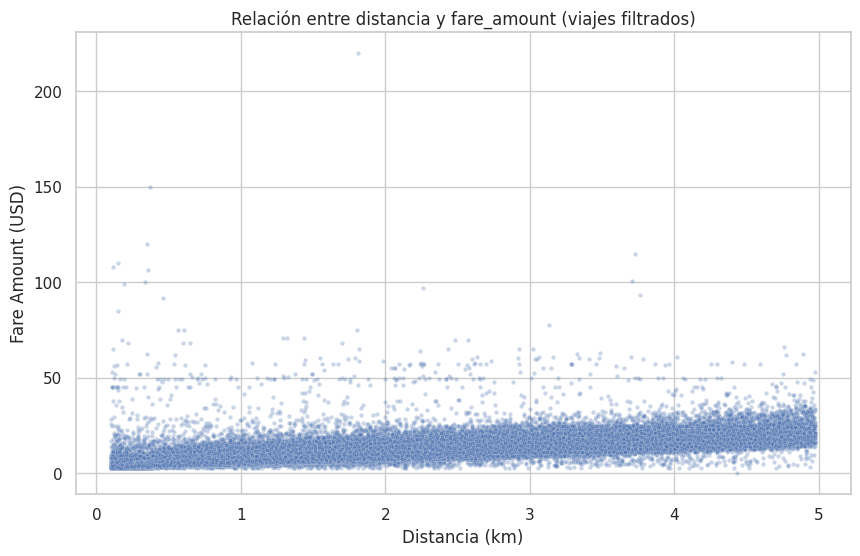

'\nsns.lmplot(data=uber, x="distancia", y="fare_amount", scatter_kws={"alpha":0.2, "s":10}, line_kws={"color":"red"})\nplt.title("Tendencia lineal entre distancia y fare_amount")\nplt.xlabel("Distancia (km)")\nplt.ylabel("Fare Amount (USD)")\nplt.grid(True)\nplt.show()\n'

In [532]:
# Grafico fare amount ANTES de la imputación

plt.figure(figsize=(10, 6))
sns.scatterplot(data=uber, x="distancia", y="fare_amount", alpha=0.3, s=10)
plt.title("Relación entre distancia y fare_amount (viajes filtrados)")
plt.xlabel("Distancia (km)")
plt.ylabel("Fare Amount (USD)")
plt.grid(True)
plt.show()
'''
sns.lmplot(data=uber, x="distancia", y="fare_amount", scatter_kws={"alpha":0.2, "s":10}, line_kws={"color":"red"})
plt.title("Tendencia lineal entre distancia y fare_amount")
plt.xlabel("Distancia (km)")
plt.ylabel("Fare Amount (USD)")
plt.grid(True)
plt.show()
'''

In [477]:
# Opcion 1: Imputación simple por la mediana de las coordenadas

from sklearn.impute import SimpleImputer

columnas_a_imputar = ['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude']

imputer = SimpleImputer(strategy='median')  # o 'mean'
uber[columnas_a_imputar] = imputer.fit_transform(uber[columnas_a_imputar])

In [184]:
# Opcion 2: Imputación knn de las coordenadas

from sklearn.impute import KNNImputer
import numpy as np

# 1. Seleccionamos las columnas de coordenadas
columnas_a_imputar = ['pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude']

# 2. Imputamos coordenadas con KNN
imputer = KNNImputer(n_neighbors=5)
coordenadas_imputadas = imputer.fit_transform(uber[columnas_a_imputar])

# 3. Agregamos ruido gaussiano pequeño
#ruido = np.random.normal(loc=0, scale=0.0005, size=coordenadas_imputadas.shape)
#coordenadas_imputadas_con_ruido = coordenadas_imputadas + ruido

# 4. Asignamos de vuelta al dataframe
uber[columnas_coords] = coordenadas_imputadas


<ipython-input-184-f73d56517f7d>:27: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.0' has dtype incompatible with datetime64[ns], please explicitly cast to a compatible dtype first.
  uber[uber["passenger_count"].isna()] = uber["passenger_count"].median()
<ipython-input-184-f73d56517f7d>:27: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.0' has dtype incompatible with datetime64[ns, UTC], please explicitly cast to a compatible dtype first.
  uber[uber["passenger_count"].isna()] = uber["passenger_count"].median()
<ipython-input-184-f73d56517f7d>:27: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.0' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  uber[uber["passenger_count"].isna()] = uber["passenger

In [533]:
# Imputo el único valor NaN de passenger_count

uber[uber["passenger_count"].isna()] = uber["passenger_count"].median()

<ipython-input-533-1a7f31b838cf>:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.0' has dtype incompatible with datetime64[ns], please explicitly cast to a compatible dtype first.
  uber[uber["passenger_count"].isna()] = uber["passenger_count"].median()
<ipython-input-533-1a7f31b838cf>:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.0' has dtype incompatible with datetime64[ns, UTC], please explicitly cast to a compatible dtype first.
  uber[uber["passenger_count"].isna()] = uber["passenger_count"].median()
<ipython-input-533-1a7f31b838cf>:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.0' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  uber[uber["passenger_count"].isna()] = uber["passenger_co

In [536]:
# Imputación simple por la mediana de la distancia

from sklearn.impute import SimpleImputer

columnas_a_imputar = ['distancia']

imputer = SimpleImputer(strategy='median')  # o 'mean'
uber[columnas_a_imputar] = imputer.fit_transform(uber[columnas_a_imputar])

In [535]:
# Recalculo la distancia despúes de haber imputado

uber["distancia"] = distancia(
    uber["pickup_latitude"],
    uber["pickup_longitude"],
    uber["dropoff_latitude"],
    uber["dropoff_longitude"]
)

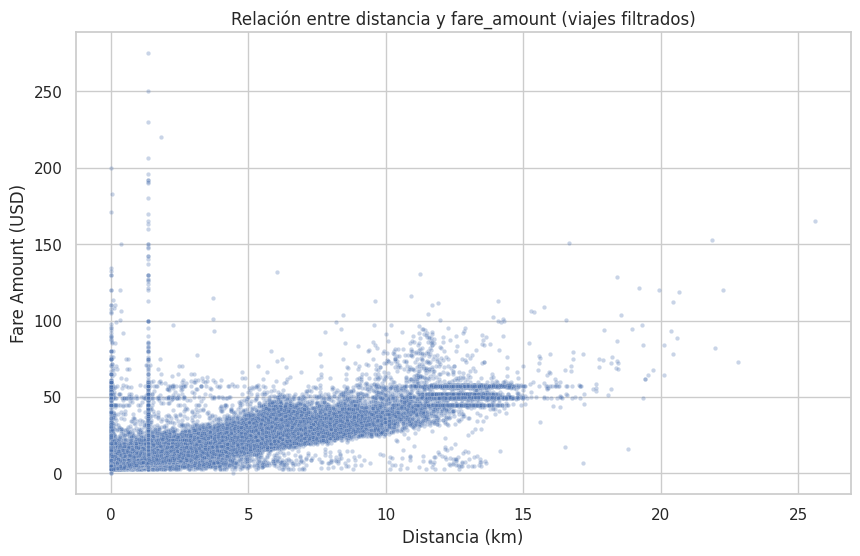

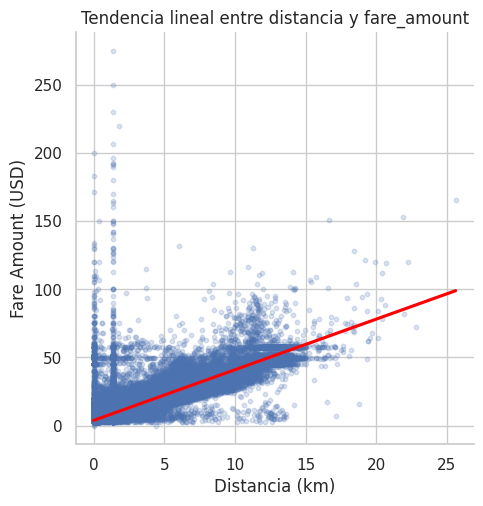

In [537]:
# Grafico fare amount DESPUÉS de la imputación

plt.figure(figsize=(10, 6))
sns.scatterplot(data=uber, x="distancia", y="fare_amount", alpha=0.3, s=10)
plt.title("Relación entre distancia y fare_amount (viajes filtrados)")
plt.xlabel("Distancia (km)")
plt.ylabel("Fare Amount (USD)")
plt.grid(True)
plt.show()

sns.lmplot(data=uber, x="distancia", y="fare_amount", scatter_kws={"alpha":0.2, "s":10}, line_kws={"color":"red"})
plt.title("Tendencia lineal entre distancia y fare_amount")
plt.xlabel("Distancia (km)")
plt.ylabel("Fare Amount (USD)")
plt.grid(True)
plt.show()


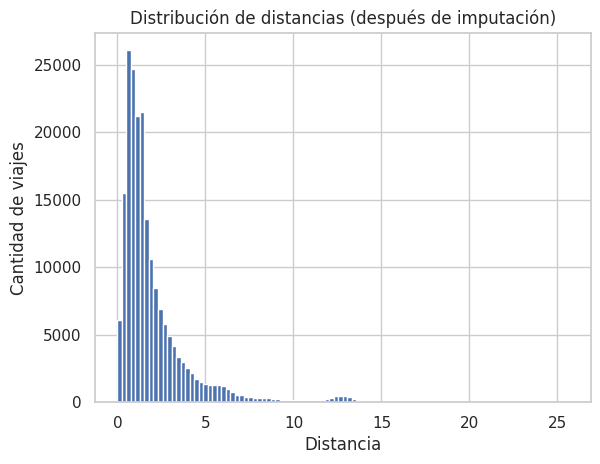

In [538]:
# Distribución de las distancias después de la imputación

plt.hist(uber['distancia'], bins=100)
plt.title("Distribución de distancias (después de imputación)")
plt.xlabel("Distancia")
plt.ylabel("Cantidad de viajes")
plt.show()

### Graficos

Text(0.5, 1.0, 'Ubicaciones de recogida y destino')

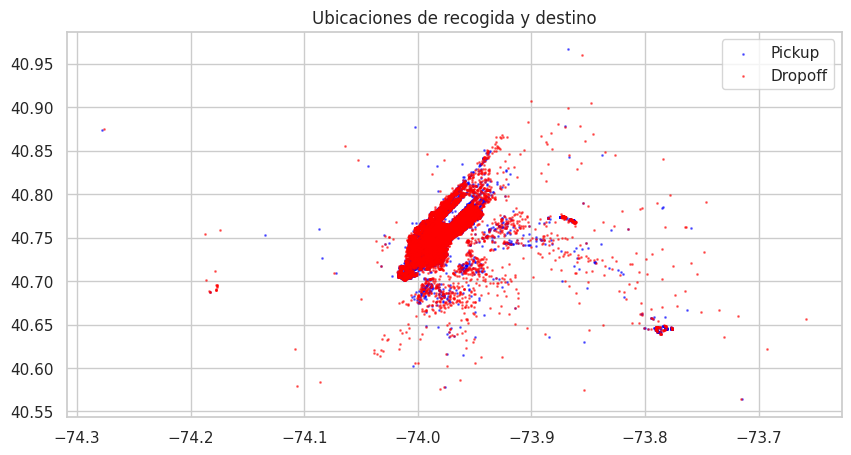

In [344]:
# Muestra una parte del dataset para evitar sobrecarga visual
sample = uber.sample(10000)
plt.figure(figsize=(10,5))
plt.scatter(sample['pickup_longitude'], sample['pickup_latitude'], c='blue', s=1, label='Pickup', alpha=0.5)
plt.scatter(sample['dropoff_longitude'], sample['dropoff_latitude'], c='red', s=1, label='Dropoff', alpha=0.5)
plt.legend()
plt.title("Ubicaciones de recogida y destino")

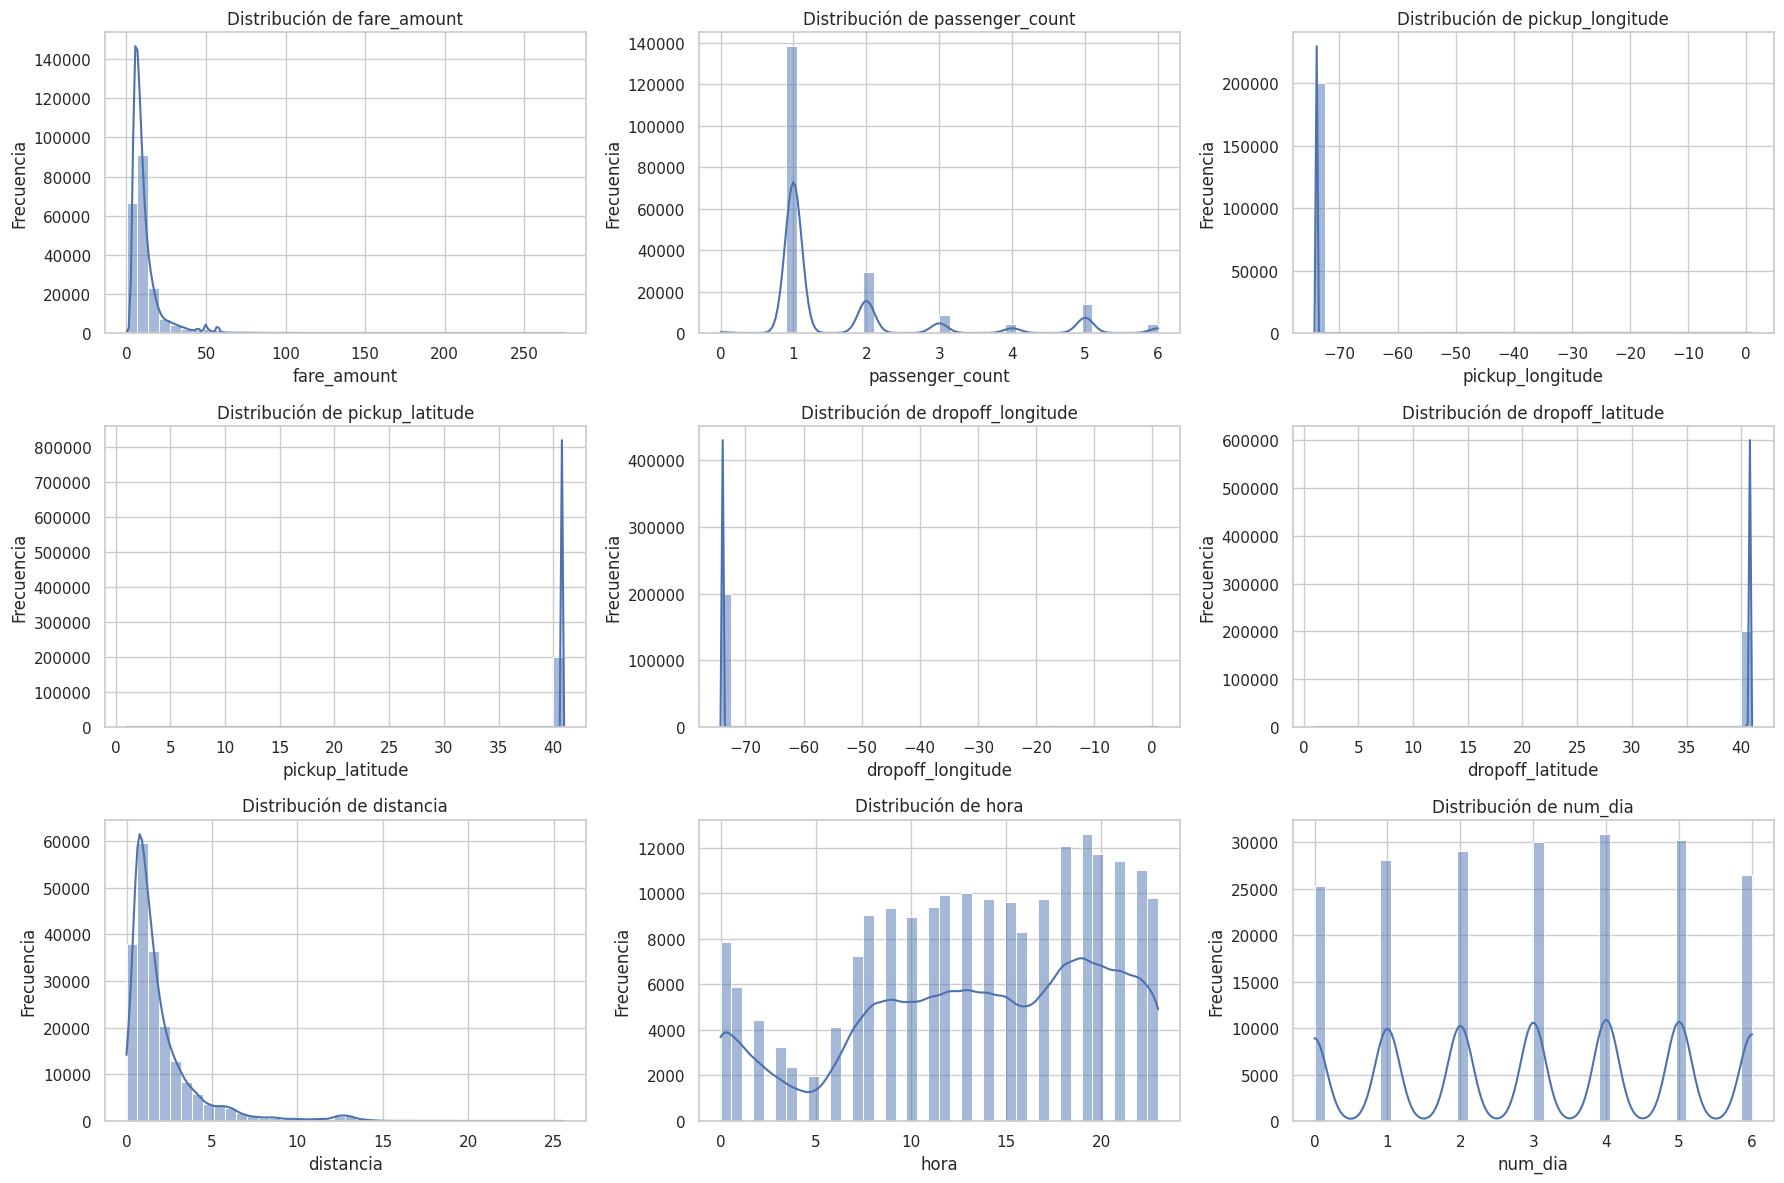

In [345]:
# Variables numéricas relevantes
variables = ["fare_amount", "passenger_count", "pickup_longitude", "pickup_latitude",
             "dropoff_longitude", "dropoff_latitude", "distancia", "hora", "num_dia"]

# Estilo
sns.set(style="whitegrid")

# Creamos los subplots
fig, axs = plt.subplots(3, 3, figsize=(18, 12))
axs = axs.flatten()

# Generamos un histograma por cada variable
for i, col in enumerate(variables):
    sns.histplot(data=uber, x=col, bins=40, ax=axs[i], kde=True)
    axs[i].set_title(f"Distribución de {col}")
    axs[i].set_xlabel(col)
    axs[i].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

heatmap hora vs día para ver en qué momento del día hay más viajes según el día de la semana

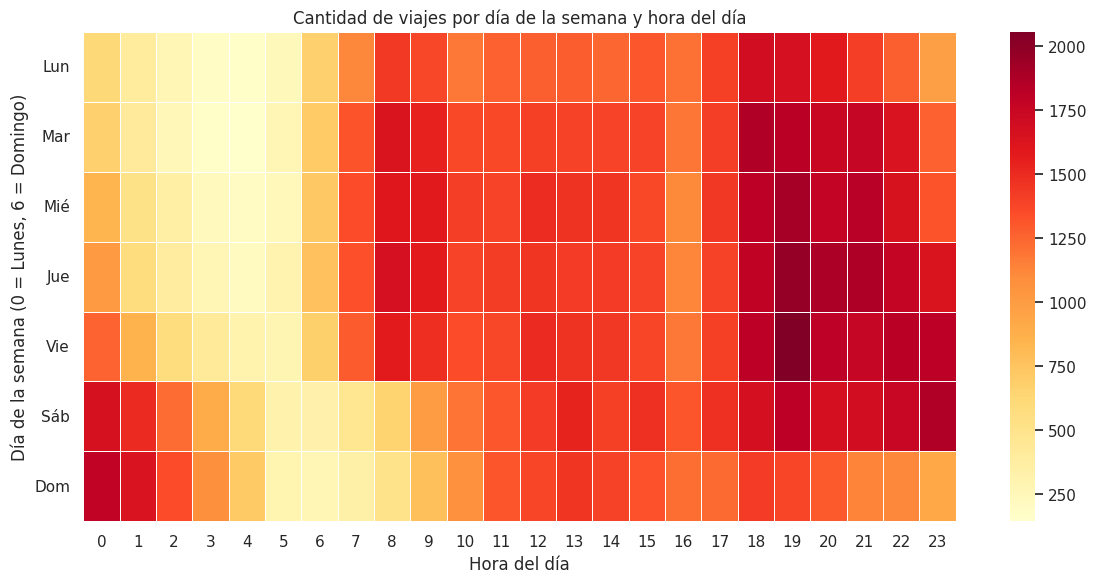

In [346]:
# Creamos una tabla resumen con la cantidad de viajes por día y hora
heatmap_data = uber.groupby(["num_dia", "hora"]).size().unstack(fill_value=0)

# Creamos el heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap="YlOrRd", annot=False, linewidths=0.5)

# Títulos y etiquetas
plt.title("Cantidad de viajes por día de la semana y hora del día")
plt.xlabel("Hora del día")
plt.ylabel("Día de la semana (0 = Lunes, 6 = Domingo)")
plt.yticks(ticks=[i + 0.5 for i in range(7)], labels=["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"], rotation=0)

plt.tight_layout()
plt.show()

fare_amount

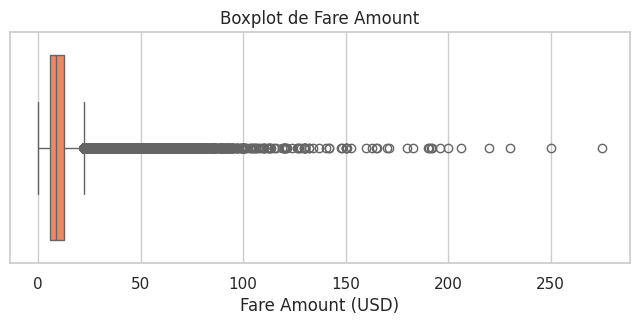

In [347]:
plt.figure(figsize=(8, 3))
sns.boxplot(x=uber["fare_amount"], color="coral")
plt.title("Boxplot de Fare Amount")
plt.xlabel("Fare Amount (USD)")
plt.show()


passenger_count vs fare_amount (¿hay correlación entre los pasajeros y el precio?)

<ipython-input-348-b73ae6cab775>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=uber, x="passenger_count", y="fare_amount", palette="Set2")


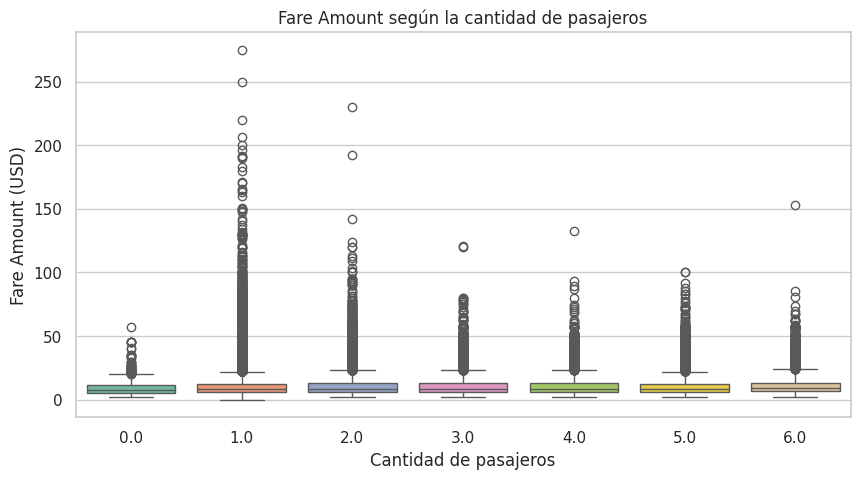

In [348]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=uber, x="passenger_count", y="fare_amount", palette="Set2")
plt.title("Fare Amount según la cantidad de pasajeros")
plt.xlabel("Cantidad de pasajeros")
plt.ylabel("Fare Amount (USD)")
plt.show()

fare_amount vs distancia

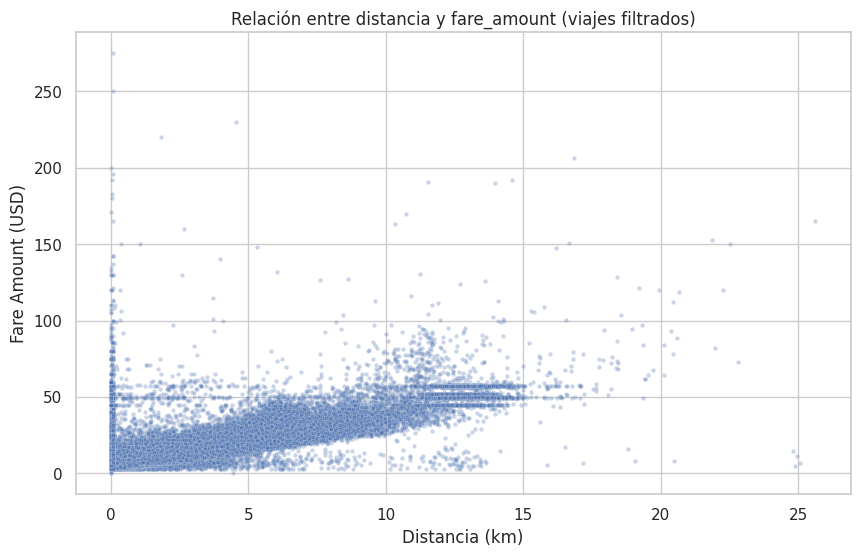

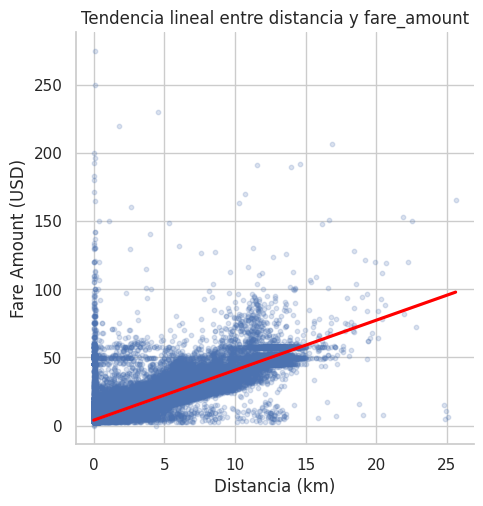

In [349]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=uber, x="distancia", y="fare_amount", alpha=0.3, s=10)
plt.title("Relación entre distancia y fare_amount (viajes filtrados)")
plt.xlabel("Distancia (km)")
plt.ylabel("Fare Amount (USD)")
plt.grid(True)
plt.show()

sns.lmplot(data=uber, x="distancia", y="fare_amount", scatter_kws={"alpha":0.2, "s":10}, line_kws={"color":"red"})
plt.title("Tendencia lineal entre distancia y fare_amount")
plt.xlabel("Distancia (km)")
plt.ylabel("Fare Amount (USD)")
plt.grid(True)
plt.show()


In [350]:
columnas_sin_corr = ["fare_amount", "passenger_count", "distancia", "día", "feriado","key","fecha","pickup_datetime"]
matriz = uber.drop(columns=columnas_sin_corr)
corr = matriz.corr()
ax = sns.heatmap(
    corr,
    vmin=-1, vmax=1, center=0,
    cmap=sns.diverging_palette(20, 220, n=200),
    square=True,
    annot = True,
    annot_kws = {'size': 6}
)
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    horizontalalignment='right'
)
plt.title("Matriz de correlación")
plt.show()

TypeError: float() argument must be a string or a real number, not 'Timestamp'

### Estandarización y division del dataset

In [539]:
'''
columnas_cualitativas = ["passenger_count","distancia"]
scaler = StandardScaler().set_output(transform="pandas")
X_estandarizado = scaler.fit_transform(uber[columnas_cualitativas])
X_estandarizado["feriado"] = uber["feriado"]
X_estandarizado["dia"] = uber["num_dia"]
X_estandarizado["hora"] = uber["hora"]
y = uber["fare_amount"]
'''

columnas_numericas = ["passenger_count","distancia"]
scaler = StandardScaler().set_output(transform="pandas")

# Escalar y resetear índice
X_scaled = scaler.fit_transform(uber[columnas_numericas]).reset_index(drop=True)

# Concatenar con otras columnas (también con índice reseteado)
otras_columnas = uber[["feriado", "num_dia", "hora"]].reset_index(drop=True)

# Combinar todo
X_estandarizado = pd.concat([X_scaled, otras_columnas], axis=1)

# Target
y = uber["fare_amount"].reset_index(drop=True)

In [540]:
X_train, X_test, y_train, y_test = train_test_split(X_estandarizado, y, test_size=0.2, random_state=42)

## Modelos de regresión

### Regresión lineal
$$
\text{fare\_amount} = 11.69 + 0.099 \cdot \text{passenger\_count} + 0.542 \cdot \text{distancia} - 0.0077 \cdot \text{feriado} + 0.0247 \cdot \text{dia} - 0.0311 \cdot \text{hora}
$$

In [541]:
X_train.columns

Index(['passenger_count', 'distancia', 'feriado', 'num_dia', 'hora'], dtype='object')

In [542]:
modelo = LinearRegression().fit(X_train,y_train)

In [543]:
modelo.coef_

array([ 3.75552291e-02,  8.19284069e+00, -5.31821177e-01, -3.93764401e-02,
        6.78295066e-03])

In [544]:
modelo.intercept_

np.float64(11.401401417371853)

In [548]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Predicciones
y_pred_train = modelo.predict(X_train)
y_pred_test = modelo.predict(X_test)

# Métricas
def print_metrics(y_true, y_pred, dataset=""):
    print(f"--- {dataset} ---")
    print("R2 Score:", r2_score(y_true, y_pred))
    print("MSE:", mean_squared_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("MAE:", mean_absolute_error(y_true, y_pred))

print_metrics(y_train, y_pred_train, "Entrenamiento")
print_metrics(y_test, y_pred_test, "Prueba")


#  R2 Score: Qué proporción de la varianza del target explica el modelo (idealmente cerca de 1).

#  MSE / RMSE: Error cuadrático medio y su raíz, útiles para penalizar errores grandes.

#  MAE: Error absoluto medio (más robusto ante outliers).

--- Entrenamiento ---
R2 Score: 0.6932340233634297
MSE: 29.870987530524406
RMSE: 5.465435712779394
MAE: 2.5423157422758123
--- Prueba ---
R2 Score: 0.7024694596099561
MSE: 27.209461070738456
RMSE: 5.216268884052897
MAE: 2.5165561558135696


### Gradiente descendiente

In [549]:
from sklearn.linear_model import SGDRegressor
import matplotlib.pyplot as plt

sgd = SGDRegressor(loss='squared_error', penalty=None, learning_rate='invscaling', eta0=0.01, max_iter=1000, random_state=42)
sgd.fit(X_train, y_train)

y_pred_sgd_train = sgd.predict(X_train)
y_pred_sgd_test = sgd.predict(X_test)

print_metrics(y_train, y_pred_sgd_train, "Entrenamiento (SGD)")
print_metrics(y_test, y_pred_sgd_test, "Prueba (SGD)")


--- Entrenamiento (SGD) ---
R2 Score: 0.6906975032987477
MSE: 30.117978282412135
RMSE: 5.487984901802495
MAE: 2.4479930353807355
--- Prueba (SGD) ---
R2 Score: 0.6998957125068401
MSE: 27.444832779190154
RMSE: 5.238781612091704
MAE: 2.4252871117875414
